---
title: "Reading geostationary products: MSG SEVIRI, MTG FCI and the Lightning Imager with DEFAIR" 
subtitle: "This tutorial shows how to read three of the families of geostationary satellite products MSG SEVIRI, using DEFAIR"
author: "Author: Erwan Fassot (Oxidian)"
tags: [DEFAIR,EUMETSAT,MSG SEVIRI,MTG FCI,MTG Lightning Imager]
thumbnail: img/EUMETSAT_TEST.png 
license: MIT
copyright: "© 2026 EUMETSAT"
---

<!-- Optional: Add a JupyterHub launch link here. If you don’t have one, you can remove this block. -->

<div style="margin: 6px 0;">
  <a href="https://jupyter.central.data.destination-earth.eu/user-redirect/lab/tree/template1.ipynb" target="_blank" style="text-decoration: none;">
    <span class="launch">🚀 Launch in JupyterHub</span>
  </a>
</div>


# Reading geostationary products: MSG SEVIRI, MTG FCI and the Lightning Imager with DEFAIR

A geostationary satellite holds station over one meridian and images the same disc of the
Earth every few minutes. This tutorial reads three of the families DEFAIR supports from that
orbit: MSG SEVIRI, the instrument that has been flying for two decades; MTG FCI, its
successor, in both its normal and high resolution forms; and the MTG Lightning Imager, whose
flash-location product reports individual flashes rather than an image.

The last one is the interesting case. DEFAIR returns lightning as point data, with a
coordinate per flash rather than a grid, and the same `Dataset.from_source` call produces it.

### Contents

- **Objective:** Demonstrate how to read, inspect, and visualize geostationary satellite products using **DEFAIR**, covering imagery from **MSG SEVIRI**, **MTG FCI**, and lightning observations from the **MTG Lightning Imager**.
- **Data Sources:**
    - [MSG SEVIRI High Rate SEVIRI (Level 1.5)](https://data.eumetsat.int/product/EO:EUM:DAT:MSG:HRSEVIRI)
    -  SEVIRI Climate Data Records,
    -  SEVIRI Climate Data Records,
    -  MTG FCI Level-1c imagery,
    -  and MTG Lightning Imager observations
    Example datasets are hosted in the [DestinE Data Lake demonstration bucket](https://s3.central.data.destination-earth.eu/swift/v1/datalake-demo-data/).
- **Methods:** This notebook illustrates a common DEFAIR workflow for geostationary Earth observation products:
    * Access datasets stored in cloud object storage.
    * Read products using the Dataset.from_source() interface.
    * Inspect dataset structure, dimensions, coordinates, and variables.
    * Visualize geolocated observations on their native geostationary projection.
    * Compare reading workflows across multiple satellite missions and product types.
- **Prerequisites:** Before running this notebook, ensure that:
    *  DEFAIR is installed and configured.
- **Expected Output:** At the end of this notebook, users will be able to:
    *  Open geostationary products from different satellite missions using a consistent API.
    *  Explore dataset metadata and structure.
    *  Generate quicklook visualizations for image products.
    *  Display lightning observations from the MTG Lightning Imager.
    *  Understand how DEFAIR harmonizes access to both gridded satellite imagery and point-based geophysical observations.

(template.ipynb-Prerequisites)=
## Prerequisites


## Imports

In [1]:
from pathlib import Path

import numpy as np

from defair_data.core import Dataset
from defair_data.dask_manager import close_dask_client
from defair.logging import setup_logging
from defair.plugin_manager import load_source

# Readers log every step at DEBUG. WARNING keeps this notebook's output to what the
# tutorial prints, and is the level to raise when a read does something unexpected.
setup_logging(log_level="WARNING")

import matplotlib.pyplot as plt

try:
    import cartopy.crs as ccrs

    HAS_CARTOPY = True
except ImportError:
    HAS_CARTOPY = False
    print("cartopy not installed, maps will be drawn without coastlines")

OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)


In [2]:
def quicklook(dataset, variable, title, cmap="viridis"):
    """Draw one variable of a DEFAIR dataset on its native geostationary grid.

    Every product below is read through the same call and drawn through this same
    helper, which is the point of the tutorial: the reader differs, the shape of the
    work does not. A geostationary read keeps the instrument's own projection grid, so
    the dataset carries x and y in projection coordinates rather than longitude and
    latitude. Plotting against those real coordinates (rather than assuming row 0 is
    always the north, the way a plain pixel image would) is what keeps this correct
    regardless of which way a reader's own row order happens to run: these readers
    return y descending (row 0 = north) by default, while a native-order read can
    ascend, and either is simply drawn at its true position -- no reader-specific
    case needed. Coastlines come from the dataset's own CRS, so a genuinely
    misplaced disc would show up as a mismatch against them, not just a guess from
    the raw pixels. The reprojection tutorial is where this native grid becomes a
    map in a fixed frame like EPSG:4326.
    """
    field = dataset.data[variable].squeeze(drop=True)
    # Reduce whatever remains to two dimensions. Products name their extra axes
    # differently (time, band, channel), so take the first index of the leading axis
    # until an image is left rather than naming the axes.
    while field.ndim > 2:
        field = field.isel({field.dims[0]: 0})
    y_dim, x_dim = field.dims

    # A quicklook does not need native resolution: HRFI's full disc at 500 m is
    # 22272x22272 (~500M cells, 2 GB in float32 before any copy). Decimate while the
    # array is still lazy, so only the pixels drawn are ever held in memory.
    max_dim = 2000
    field = field.isel({
        y_dim: slice(None, None, max(1, field.sizes[y_dim] // max_dim)),
        x_dim: slice(None, None, max(1, field.sizes[x_dim] // max_dim)),
    })
    values = np.asarray(field.compute().values, dtype=float)
    x = np.asarray(field[x_dim].values, dtype=float)
    y = np.asarray(field[y_dim].values, dtype=float)

    finite = values[np.isfinite(values)]
    if finite.size == 0:
        print(f"{title}: no finite values to draw")
        return
    vmin, vmax = np.percentile(finite, [2, 98])

    figure = plt.figure(figsize=(9, 9))
    if HAS_CARTOPY:
        attrs = dataset.data["spatial_ref"].attrs
        globe = ccrs.Globe(
            semimajor_axis=attrs["semi_major_axis"], semiminor_axis=attrs["semi_minor_axis"], ellipse=None
        )
        projection = ccrs.Geostationary(
            central_longitude=attrs["longitude_of_projection_origin"],
            satellite_height=attrs["perspective_point_height"],
            sweep_axis=attrs["sweep_angle_axis"],
            globe=globe,
        )
        axis = plt.axes(projection=projection)
        image = axis.pcolormesh(x, y, values, transform=projection, cmap=cmap, vmin=vmin, vmax=vmax, shading="auto")
        axis.coastlines(resolution="50m", linewidth=0.8, color="white")
    else:
        axis = plt.axes()
        image = axis.pcolormesh(x, y, values, cmap=cmap, vmin=vmin, vmax=vmax, shading="auto")
        axis.set_aspect("equal")
        axis.set_xlabel("x (m)")
        axis.set_ylabel("y (m)")
    axis.set_title(title, fontsize=13, fontweight="bold")
    units = dataset.data[variable].attrs.get("units", "")
    figure.colorbar(image, ax=axis, label=f"{variable} ({units})" if units else variable, shrink=0.8)
    plt.tight_layout()
    plt.show()


def inventory(dataset, label):
    """Print what a read produced, so each section shows the model DEFAIR built."""
    print(f"{label}")
    print(f"  dimensions: {dict(dataset.data.sizes)}")
    print(f"  variables:  {list(dataset.data.data_vars)[:8]}")
    print(f"  coordinates: {list(dataset.data.coords)[:8]}")


## MSG SEVIRI

`use_channel_names=True` asks the reader for the documented channel names rather than the
raw band numbers, so the selection below reads as what it is: the 10.8 micron infrared
window.

The read returns two variables: the channel, and `geostationary`, the CF grid-mapping
variable that carries the projection its pixel coordinates refer to. A reprojection has
nothing to resample in it, so it skips the variable and writes a grid mapping for the target
grid instead, which is the warning the reprojection tutorials print.

In [4]:
MSG_URI = "s3://datalake-demo-data/defair-notebook-data/msg-seviri-l15/MSG3-SEVI-MSG15-0100-NA-20251016172744.081000000Z-NA_nat"
msg = Dataset.from_source(MSG_URI, reader="msg15nat", source="s3", use_channel_names=True, channels=["IR_108"],source_kwargs={"anon": True, "endpoint_url": "https://s3.central.data.destination-earth.eu"})
inventory(msg, "MSG SEVIRI 1.5")

MSG SEVIRI 1.5
  dimensions: {'time': 1, 'y': 3712, 'x': 3712, 'bnds': 2}
  variables:  ['IR_108', 'geostationary']
  coordinates: ['time', 'x', 'y', 'spatial_ref', 'time_bnds']


2026-09-28 23:54:26 | WARNING  | [a9026876] distributed.worker_memory:_spill:315 - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 2.83 GiB -- Worker memory limit: 4.00 GiB


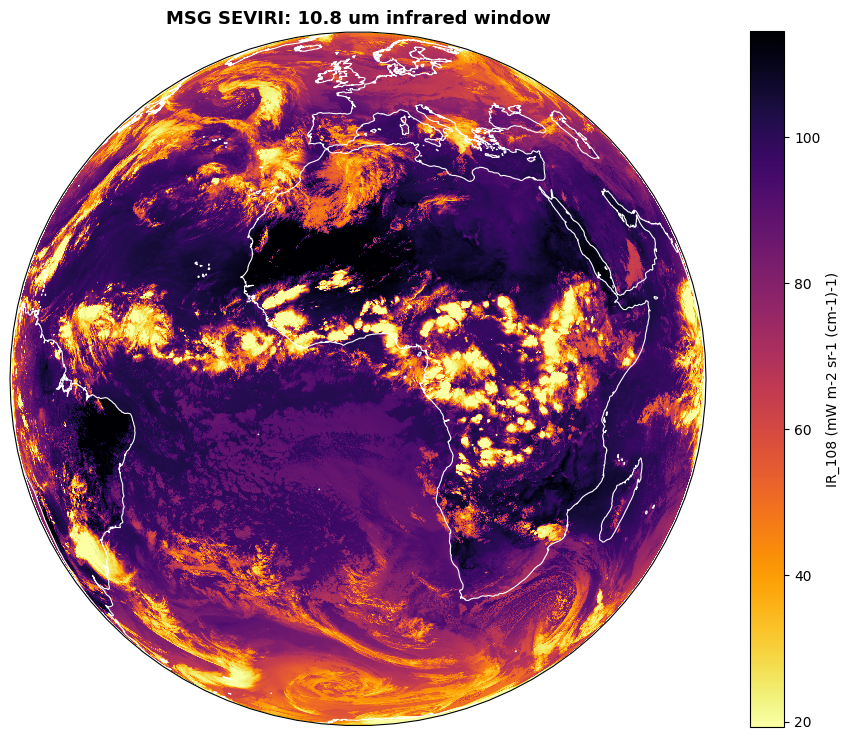

In [5]:
quicklook(msg, "IR_108", "MSG SEVIRI: 10.8 um infrared window", cmap="inferno_r")

## MSG SEVIRI Climate Data Record (CDR): Full Disk

EUMETSAT also reprocesses SEVIRI into the Level 1.5 Climate Data Record: archived counts
identified by DOI rather than a Data Store collection ID (the `product`/`doi` attributes
below come from the file itself, not a hardcoded value), with a second, recalibrated set of
radiometric coefficients for scenes EUMETSAT has reprocessed. `msg15cdr` shares `msg15nat`'s
channel names and calibration modes, calibrates with the operational coefficients by default
(`calibration_source="prefer"` or `"recalibrated"` opts into the recalibrated set where a file
provides it), and reads both Full Disk and Rapid Scan through the same reader -- it
auto-detects the variant from the file's own row extent, shown here and in the Rapid Scan
section below.

In [8]:
FD_CDR_URI = (
    "s3://datalake-demo-data/defair-notebook-data/msg-seviri-cdr/"
    "W_XX-EUMETSAT-Darmstadt,VIS+IR+HRV+IMAGERY,MSG2+SEVIRI_C_EUMG_20220118121510Z_20220118122742Z_1_OR_FES_E0000_0100"
)

fd_cdr = Dataset.from_source(FD_CDR_URI, reader="msg15cdr", source="s3", use_channel_names=True, channels=["IR_108"],source_kwargs={"anon": True, "endpoint_url": "https://s3.central.data.destination-earth.eu"})
inventory(fd_cdr, "MSG SEVIRI CDR - Full Disk")

MSG SEVIRI CDR - Full Disk
  dimensions: {'time': 1, 'y': 3712, 'x': 3712, 'bnds': 2}
  variables:  ['IR_108']
  coordinates: ['time', 'x', 'y', 'lat', 'lon', 'time_bnds', 'spatial_ref']


2026-09-28 23:52:57 | WARNING  | [544b29f7] defair_data.dask_manager:release_client:717 - Release called but ref_count is already 0


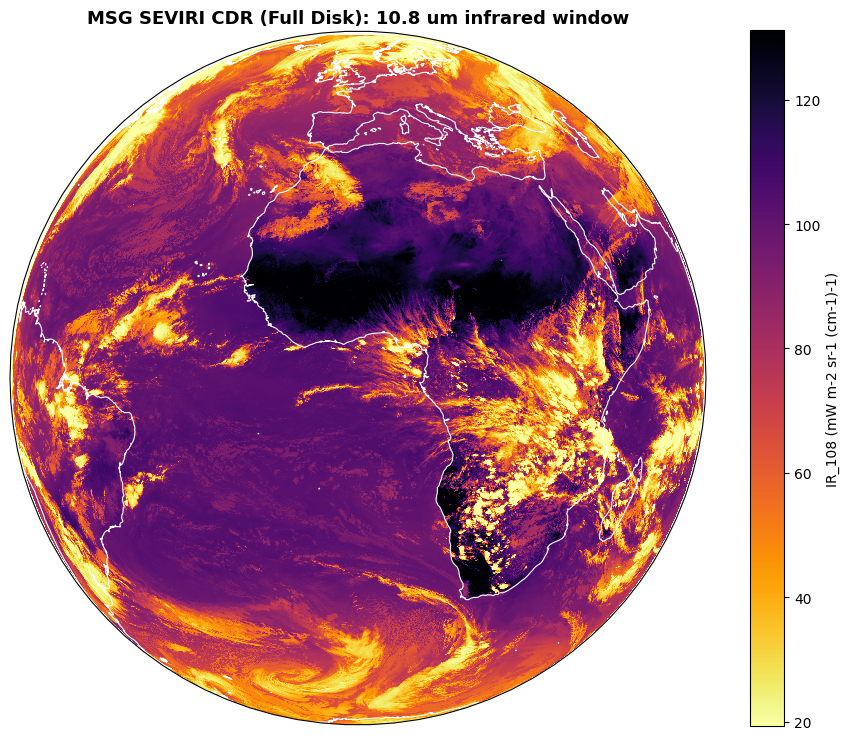

In [10]:
quicklook(fd_cdr, "IR_108", "MSG SEVIRI CDR (Full Disk): 10.8 um infrared window", cmap="inferno_r")

## MSG SEVIRI Climate Data Record (CDR): Rapid Scan

The Rapid Scan CDR is the same reader and the same file layout over a narrower disc:
EUMETSAT's Rapid Scan service revisits Europe every five minutes instead of the Full Disk's
fifteen. Recalibration on this product is only available for scenes before April 2020, and
only for the infrared and water-vapour channels -- this scene predates that cutoff, so its
own `measurements/calibration` group carries both coefficient sets for the infrared channels,
even though the visible channel shown here keeps its operational one.

In [11]:
RSS_CDR_URI = (
    "s3://datalake-demo-data/defair-notebook-data/msg-seviri-cdr/"
    "W_XX-EUMETSAT-Darmstadt,VIS+IR+HRV+IMAGERY,MSG3+SEVIRI_C_EUMG_20191101122916_0100.nc"
)

rss_cdr = Dataset.from_source(RSS_CDR_URI, reader="msg15cdr", source="s3", use_channel_names=True, channels=["VIS006"],source_kwargs={"anon": True, "endpoint_url": "https://s3.central.data.destination-earth.eu"})
inventory(rss_cdr, "MSG SEVIRI CDR - Rapid Scan")

MSG SEVIRI CDR - Rapid Scan
  dimensions: {'time': 1, 'y': 1392, 'x': 3712, 'bnds': 2}
  variables:  ['VIS006']
  coordinates: ['time', 'x', 'y', 'lat', 'lon', 'time_bnds', 'spatial_ref']


2026-09-28 23:56:46 | WARNING  | [544b29f7] defair_data.dask_manager:release_client:717 - Release called but ref_count is already 0


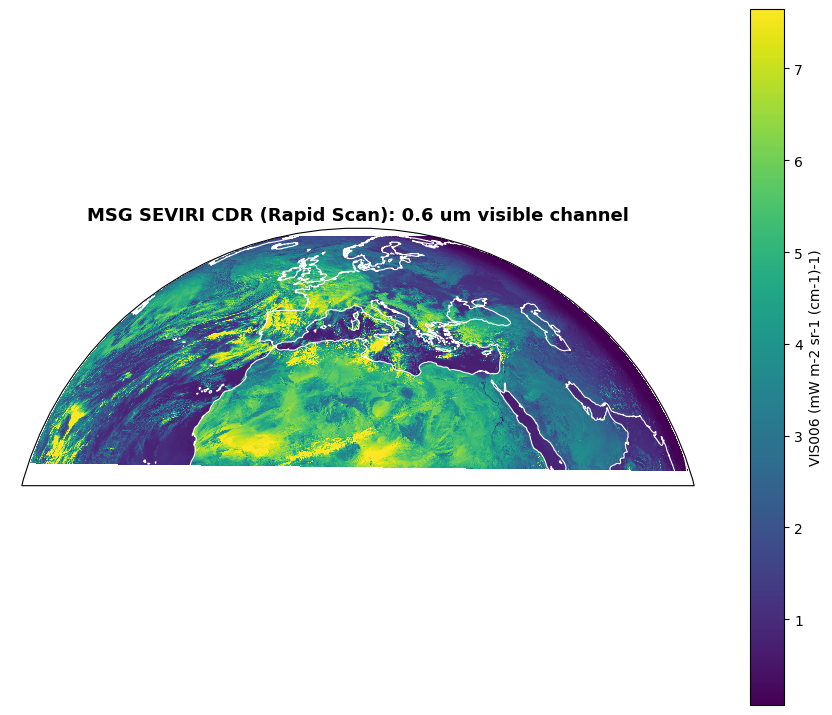

In [12]:
quicklook(rss_cdr, "VIS006", "MSG SEVIRI CDR (Rapid Scan): 0.6 um visible channel")

## MTG FCI Level-1c, normal resolution

FCI delivers a scene as a set of chunk files, each a horizontal slice of the disc. Handing
the reader the list of chunks gives one dataset for the whole scene.

In [19]:
s3 = load_source("s3",endpoint_url="https://s3.central.data.destination-earth.eu",anon=True)

def fci_scenes(prefix):
    """The scene directories under an FCI test-data prefix, one per repeat cycle.

    The listing also returns a folder marker for the prefix itself and loose chunk
    files belonging to other fixtures, and neither is a scene.
    """
    return [
        entry
        for entry in sorted(s3.list(prefix))
        if not entry.endswith(".nc") and entry.rstrip("/") != prefix.rstrip("/")
    ]


# The listing shows what the bucket holds. The scene read below is pinned by name so
# the tutorial reads the same repeat cycle every time.
FDHSI_PREFIX = "s3://datalake-demo-data/defair-notebook-data/mtg-fci-l1c-fdhsi/"
FDHSI_SCENE = (
    FDHSI_PREFIX
    + "W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-1C-RRAD-FDHSI-FD--x-x---x"
    "_C_EUMT_20251215090305_IDPFI_OPE_20251215090007_20251215090923_N__O_0055_0000/"
)
assert FDHSI_SCENE.rstrip("/") in {s.rstrip("/") for s in fci_scenes(FDHSI_PREFIX)}, (
    f"scene not found under {FDHSI_PREFIX}: {FDHSI_SCENE}"
)
fdhsi_chunks = sorted(f for f in s3.list(FDHSI_SCENE) if "CHK-BODY" in f)
print(f"scene: {FDHSI_SCENE.rstrip('/').split('/')[-1]}")
print(f"chunks: {len(fdhsi_chunks)}")

fdhsi = Dataset.from_source(
    fdhsi_chunks, reader="mtg_fci_l1c_nc", source="s3", use_channel_names=True, channels=["vis_06"],source_kwargs={"anon": True, "endpoint_url": "https://s3.central.data.destination-earth.eu"}
)
inventory(fdhsi, "MTG FCI Level-1c FDHSI")

scene: W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-1C-RRAD-FDHSI-FD--x-x---x_C_EUMT_20251215090305_IDPFI_OPE_20251215090007_20251215090923_N__O_0055_0000
chunks: 40
MTG FCI Level-1c FDHSI
  dimensions: {'time': 1, 'y_1km': 11136, 'x_1km': 11136, 'bnds': 2}
  variables:  ['vis_06']
  coordinates: ['time', 'x_1km', 'y_1km', 'spatial_ref', 'time_bnds']


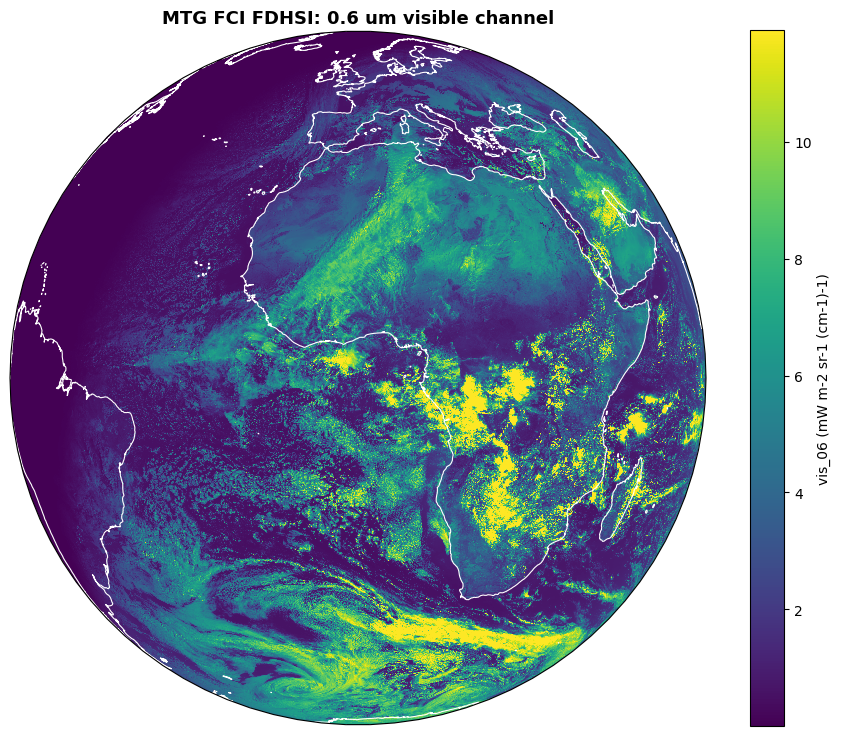

In [20]:
quicklook(fdhsi, "vis_06", "MTG FCI FDHSI: 0.6 um visible channel")

In [21]:
# Orientation is a property of the read, not of the drawing: a flipped native grid
# still plots as a plausible disc, so the row order is an assertion rather than an
# eyeball.
assert msg.data["y"].values[0] > msg.data["y"].values[-1], "MSG native y is not north-first"
assert fdhsi.data["y_1km"].values[0] > fdhsi.data["y_1km"].values[-1], "FCI y is not north-first"
print("default row order holds: MSG north-first, FCI north-first")

default row order holds: MSG north-first, FCI north-first


## MTG FCI Level-1c, high resolution

The high resolution product covers a subset of the channels at twice the sampling. Same
reader, same call: the reader recognises which product it has been handed.

In [24]:
HRFI_PREFIX = "s3://datalake-demo-data/defair-notebook-data/mtg-fci-l1c-hrfi/"
HRFI_SCENE = (
    HRFI_PREFIX
    + "W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-1C-RRAD-HRFI-FD--x-x---x"
    "_C_EUMT_20251215090305_IDPFI_OPE_20251215090007_20251215090923_N__O_0055_0000/"
)
assert HRFI_SCENE.rstrip("/") in {s.rstrip("/") for s in fci_scenes(HRFI_PREFIX)}, (
    f"scene not found under {HRFI_PREFIX}: {HRFI_SCENE}"
)
hrfi_chunks = sorted(f for f in s3.list(HRFI_SCENE) if "CHK-BODY" in f)
print(f"scene: {HRFI_SCENE.rstrip('/').split('/')[-1]}")
print(f"chunks: {len(hrfi_chunks)}")

hrfi = Dataset.from_source(hrfi_chunks, reader="mtg_fci_l1c_nc", source="s3", use_channel_names=True,source_kwargs={"anon": True, "endpoint_url": "https://s3.central.data.destination-earth.eu"})
inventory(hrfi, "MTG FCI Level-1c HRFI")
print(f"\nHRFI channels: {list(hrfi.data.data_vars)}")

scene: W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-1C-RRAD-HRFI-FD--x-x---x_C_EUMT_20251215090305_IDPFI_OPE_20251215090007_20251215090923_N__O_0055_0000
chunks: 40
MTG FCI Level-1c HRFI
  dimensions: {'time': 1, 'y_500m': 22272, 'x_500m': 22272, 'y_1km': 11136, 'x_1km': 11136, 'bnds': 2}
  variables:  ['vis_06', 'nir_22', 'ir_38', 'ir_105']
  coordinates: ['time', 'x_500m', 'y_500m', 'spatial_ref', 'x_1km', 'y_1km', 'time_bnds']

HRFI channels: ['vis_06', 'nir_22', 'ir_38', 'ir_105']


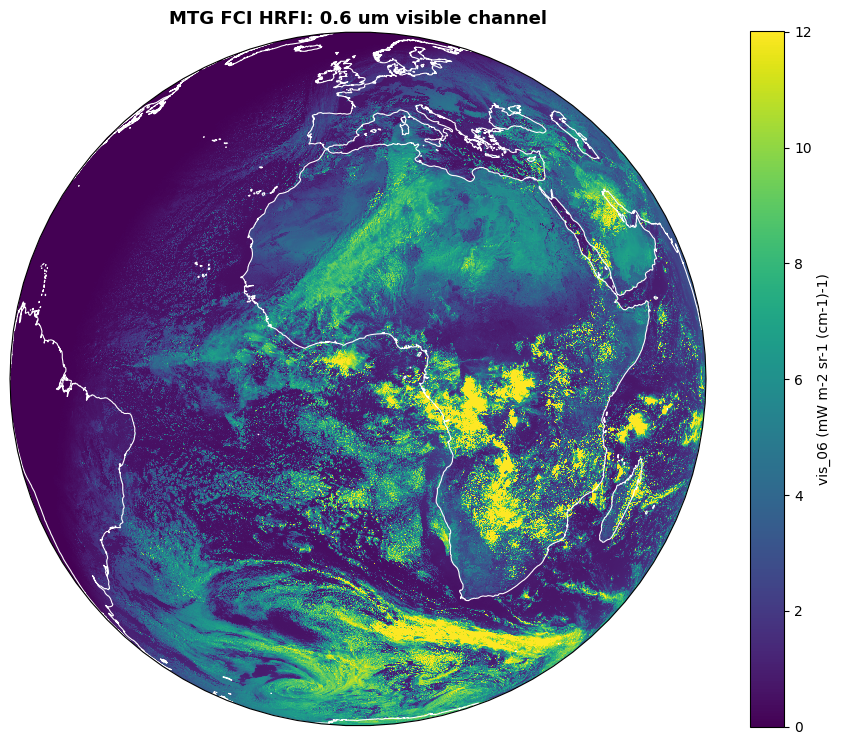

In [25]:
quicklook(hrfi, "vis_06", "MTG FCI HRFI: 0.6 um visible channel")

## MTG Lightning Imager: point data

The LFL product read here contains flash locations as points rather than an image. It
reports flashes, each with its own time and position, and DEFAIR returns them as point
data: one dimension over flashes, with
latitude and longitude as coordinates along it rather than as axes of a grid. The plotting
below is a scatter for that reason, not a raster. The instrument also has gridded
accumulated products, which are read as rasters like any other grid.

In [26]:
LFL_PREFIX = "s3://datalake-demo-data/defair-notebook-data/mtg-li-lfl/"
lfl_files = sorted(s3.list(LFL_PREFIX, pattern="*LI-2-LFL*.nc"))
LFL_GRANULE = (
    LFL_PREFIX
    + "W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+LI-2-LFL--FD--x-x--ARC-x"
    "_C_EUMT_20251210071016_L2PF_OPE_20251210070000_20251210071000_N__O_0043_0000_nat.nc"
)
assert LFL_GRANULE in lfl_files, f"granule not found under {LFL_PREFIX}: {LFL_GRANULE}"
print(f"granule: {LFL_GRANULE.split('/')[-1]}")

lightning = Dataset.from_source(LFL_GRANULE, reader="mtg_li_lfl", source="s3", reconstruction="point",source_kwargs={"anon": True, "endpoint_url": "https://s3.central.data.destination-earth.eu"})
inventory(lightning, "MTG Lightning Imager, flash locations")

granule: W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+LI-2-LFL--FD--x-x--ARC-x_C_EUMT_20251210071016_L2PF_OPE_20251210070000_20251210071000_N__O_0043_0000_nat.nc
MTG Lightning Imager, flash locations
  dimensions: {'time': 1, 'auxiliary_dataset': 1, 'flashes': 2064, 'truncated_flash': 1, 'bnds': 2}
  variables:  ['auxiliary_dataset_identifier', 'auxiliary_dataset_status', 'l1b_missing_warning', 'l1b_geolocation_warning', 'l1b_radiometric_warning', 'flash_time', 'radiance', 'flash_id']
  coordinates: ['time', 'latitude', 'longitude', 'observation_time', 'time_bnds']


flashes in this granule: 2064


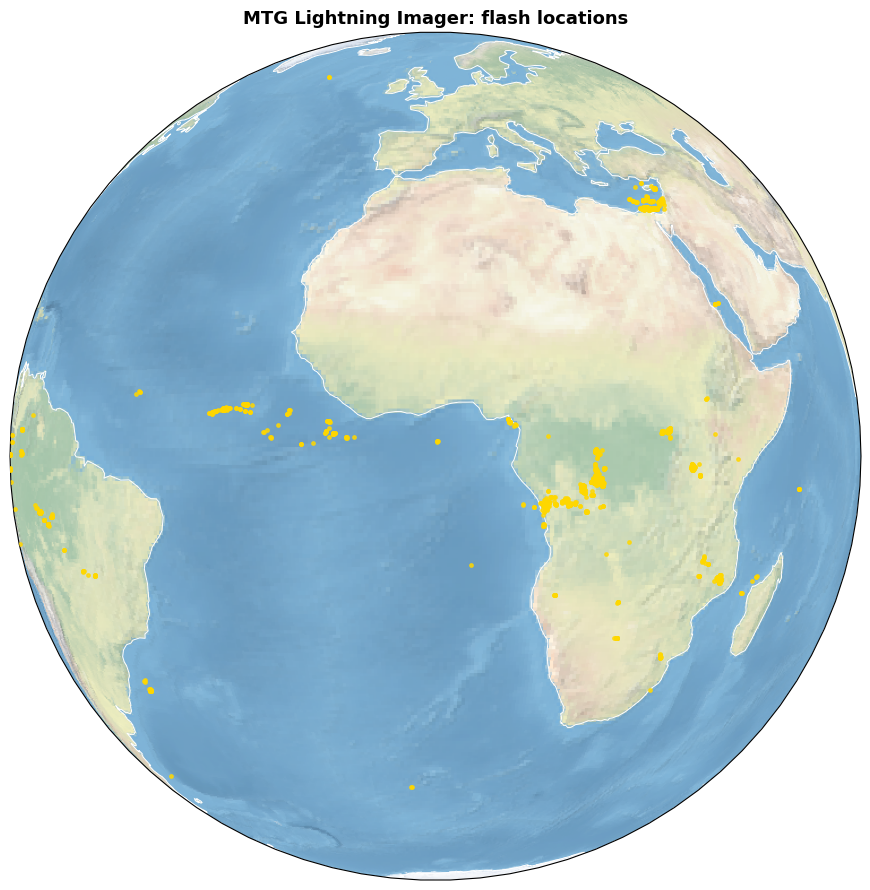

In [27]:
flashes = lightning.data.compute()
lat = np.asarray(flashes["latitude"].values, dtype=float).ravel()
lon = np.asarray(flashes["longitude"].values, dtype=float).ravel()
print(f"flashes in this granule: {lat.size}")

figure = plt.figure(figsize=(10, 9))
axis = plt.axes(projection=ccrs.Geostationary(central_longitude=0.0)) if HAS_CARTOPY else plt.axes()
kwargs = {"transform": ccrs.PlateCarree()} if HAS_CARTOPY else {}
if HAS_CARTOPY:
    axis.stock_img()
    axis.coastlines(linewidth=0.7, color="white")
axis.scatter(lon, lat, s=6, c="gold", alpha=0.8, zorder=10, **kwargs)
axis.set_title("MTG Lightning Imager: flash locations", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [28]:
close_dask_client()


## Summary
This notebook demonstrated how DEFAIR provides a unified workflow for accessing and visualizing geostationary satellite products from multiple missions and instrument generations. Using the common Dataset.from_source() interface, we explored MSG SEVIRI Level-1.5 data, SEVIRI Climate Data Records, MTG FCI Level-1c imagery, and MTG Lightning Imager observations. Through a combination of dataset inspection and geolocated quicklook visualizations, we showed how DEFAIR simplifies access to both gridded satellite imagery and point-based observations while preserving the native characteristics of each product. The key takeaway is that users can work with diverse geostationary datasets through a consistent API, reducing the effort required to integrate and analyze Earth observation data across missions.

## Resources and references
### Data Sources

EUMETSAT MSG SEVIRI High Rate SEVIRI (Level 1.5):
 https://data.eumetsat.int/product/EO:EUM:DAT:MSG:HRSEVIRI
 
### Documentation and Further Reading

[DEFAIR Documentation](https://destine-data-lake-docs.data.destination-earth.eu/en/latest)

[Meteosat Second Generation (MSG) Mission Overview]( https://www.eumetsat.int/meteosat-second-generation)

[Meteosat Third Generation (MTG) Mission Overview](https://www.eumetsat.int/meteosat-third-generation)

[MTG Flexible Combined Imager (FCI)](https://www.eumetsat.int/mtg-flexible-combined-imager)

[MTG Lightning Imager (LI)](https://www.eumetsat.int/mtg-lightning-imager)

### Acknowledgements

This notebook builds upon the DEFAIR framework and EUMETSAT datasets. The examples were adapted from the official DEFAIR documentation for the [DestinE-DataLake-Lab](https://github.com/destination-earth/DestinE-DataLake-Lab) repository to illustrate best practices for accessing and visualizing geostationary Earth observation products.